<a href="https://colab.research.google.com/github/Dillybabu03/Brand-Reputation-Analysis-Indian-Brands/blob/main/04_Predictive_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. Mount Google Drive Connection
from google.colab import drive
drive.mount('/content/drive')

# 2. Import predictive statistical packages and interface libraries
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings
warnings.filterwarnings('ignore')

print("Notebook 4 initialized successfully: Machine Learning forecasting engine standing by.")

Mounted at /content/drive
Notebook 4 initialized successfully: Machine Learning forecasting engine standing by.


Initializing Holt-Winters Forecasting Engine...


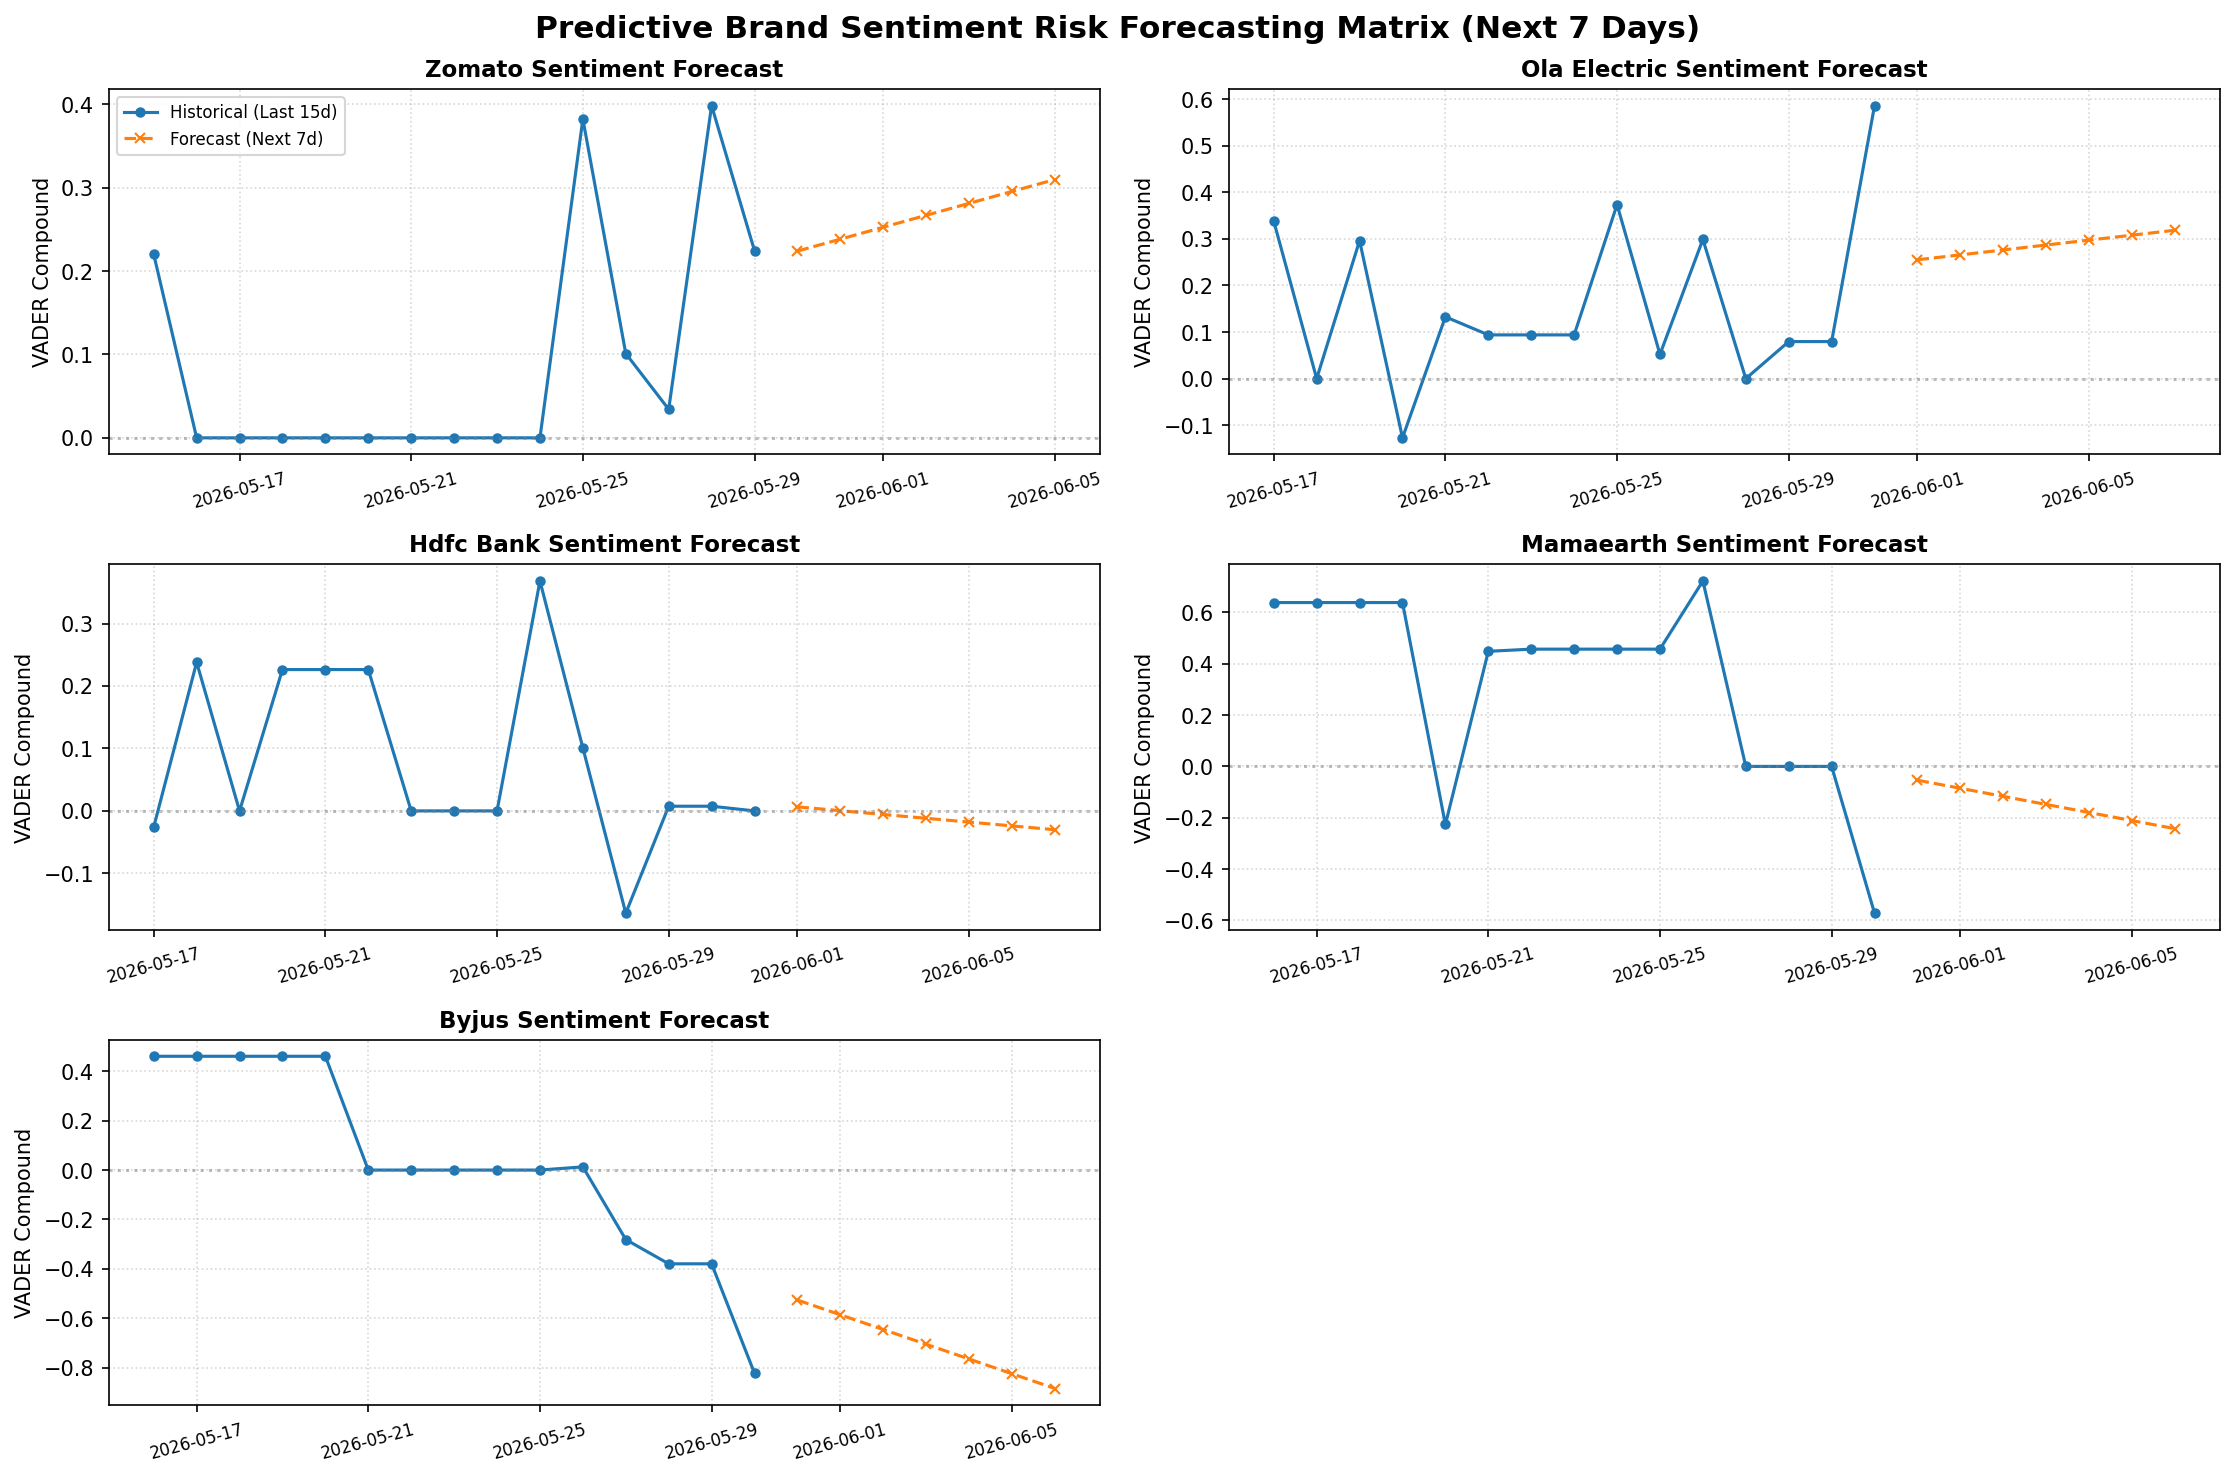


Forecasting execution complete! Visual grids saved to: /content/drive/MyDrive/SMRI_project/data/processed/brand_sentiment_predictions.png


In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

PROCESSED_DATA_PATH = '/content/drive/MyDrive/SMRI_project/data/processed'
BRANDS = ["zomato", "ola_electric", "hdfc_bank", "mamaearth", "byjus"]

print("Initializing Holt-Winters Forecasting Engine...")

plt.figure(figsize=(15, 10), dpi=150)

# Loop through each brand to forecast its future sentiment direction
for i, brand in enumerate(BRANDS, 1):
    file_path = os.path.join(PROCESSED_DATA_PATH, f"{brand}_processed_sentiment.csv")

    if os.path.exists(file_path):
        df = pd.read_csv(file_path)

        # Parse dates and group by day to get the mean VADER compound score
        time_col = 'timestamp' if 'timestamp' in df.columns else 'date'
        df['clean_date'] = pd.to_datetime(df[time_col], format='mixed').dt.date
        daily_data = df.groupby('clean_date')['vader_compound'].mean().reset_index()
        daily_data = daily_data.sort_values('clean_date').set_index('clean_date')

        # Ensure a regular daily frequency to prevent model estimation gaps
        daily_data = daily_data.asfreq('D', method='ffill')

        # Fit Holt-Winters Exponential Smoothing Model (Trend-only initialization)
        try:
            model = ExponentialSmoothing(
                daily_data['vader_compound'],
                trend='add',
                seasonal=None,
                initialization_method="estimated"
            )
            model_fit = model.fit(smoothing_level=0.3, smoothing_trend=0.1)

            # Forecast the next 7 days out into the future
            forecast_steps = 7
            forecast = model_fit.forecast(steps=forecast_steps)

            # Generate future index dates for plotting
            last_date = daily_data.index[-1]
            forecast_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=forecast_steps)

            # Plot historical vs. forecasted values across a 5-subplot matrix
            plt.subplot(3, 2, i)
            plt.plot(daily_data.index[-15:], daily_data['vader_compound'].tail(15), label='Historical (Last 15d)', color='#1F77B4', marker='o', markersize=4)
            plt.plot(forecast_dates, forecast, label='Forecast (Next 7d)', color='#FF7F0E', linestyle='--', marker='x', markersize=5)

            # Design clean visual elements for the subplots
            plt.title(f"{brand.replace('_', ' ').title()} Sentiment Forecast", fontsize=11, fontweight='bold')
            plt.axhline(0.0, color='gray', linestyle=':', alpha=0.5)
            plt.ylabel("VADER Compound")
            plt.xticks(rotation=15, fontsize=8)
            plt.grid(True, linestyle=':', alpha=0.5)
            if i == 1:
                plt.legend(fontsize=8, loc='upper left')

        except Exception as e:
            print(f"Skipping forecast calculations for {brand} due to data scale constraints: {str(e)}")

plt.suptitle("Predictive Brand Sentiment Risk Forecasting Matrix (Next 7 Days)", fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()

# Save the forecasting visual grid to your Drive directory
output_forecast_path = os.path.join(PROCESSED_DATA_PATH, 'brand_sentiment_predictions.png')
plt.savefig(output_forecast_path, bbox_inches='tight')
plt.show()

print(f"\nForecasting execution complete! Visual grids saved to: {output_forecast_path}")

In [10]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display, clear_output
from statsmodels.tsa.holtwinters import ExponentialSmoothing

PROCESSED_DATA_PATH = '/content/drive/MyDrive/SMRI_project/data/processed'
BRANDS = ["zomato", "ola_electric", "hdfc_bank", "mamaearth", "byjus"]

BRAND_LOGOS = {
    "zomato": "https://upload.wikimedia.org/wikipedia/commons/b/bd/Zomato_Logo.png",
    "ola_electric": "https://upload.wikimedia.org/wikipedia/commons/e/ee/Ola_Cabs_logo.svg",
    "hdfc_bank": "https://upload.wikimedia.org/wikipedia/commons/2/28/HDFC_Bank_Logo.svg",
    "mamaearth": "https://upload.wikimedia.org/wikipedia/commons/c/c4/Globe_icon_with_gradient.svg",
    "byjus": "https://upload.wikimedia.org/wikipedia/commons/6/66/Byju%27s_Logo.svg"
}

brand_colors = {
    "zomato": "#E23744", "ola_electric": "#A2C523", "hdfc_bank": "#1D4586", "mamaearth": "#58B947", "byjus": "#802681"
}
pie_colors = ['#4CAF50', '#FFEB3B', '#F44336']

output_area = widgets.Output()

def display_brand_dashboard(change):
    brand_selected = change['new']

    with output_area:
        clear_output(wait=True)
        file_path = os.path.join(PROCESSED_DATA_PATH, f"{brand_selected}_processed_sentiment.csv")

        if os.path.exists(file_path):
            df = pd.read_csv(file_path)

            # --- ETL, Datetime Parsing & Metric Aggregations ---
            time_col = 'timestamp' if 'timestamp' in df.columns else 'date'
            df['clean_date'] = pd.to_datetime(df[time_col], format='mixed').dt.date

            daily_data = df.groupby('clean_date')['vader_compound'].mean().reset_index()
            daily_data = daily_data.sort_values('clean_date').set_index('clean_date')

            # Feature extraction for rolling timeline
            daily_data['smoothed'] = daily_data['vader_compound'].rolling(window=7, min_periods=1).mean()

            total_articles = len(df)
            avg_vader = df['vader_compound'].mean()
            volatility = df['vader_compound'].std()

            # Categories mapping
            df['category'] = df['vader_compound'].apply(lambda x: 'Pos' if x > 0.05 else ('Neg' if x < -0.05 else 'Neu'))
            counts = df['category'].value_counts()
            pie_shares = [counts.get('Pos', 0), counts.get('Neu', 0), counts.get('Neg', 0)]

            # --- Global Ranking Baseline Aggregator ---
            overall_scores = []
            for b in BRANDS:
                bp = os.path.join(PROCESSED_DATA_PATH, f"{b}_processed_sentiment.csv")
                if os.path.exists(bp):
                    tdf = pd.read_csv(bp)
                    overall_scores.append({'Brand': b.replace('_', ' ').title(), 'Score': tdf['vader_compound'].mean()})
            df_overall = pd.DataFrame(overall_scores).sort_values(by='Score', ascending=False)
            bar_colors = [brand_colors[b.lower().replace(' ', '_')] for b in df_overall['Brand']]

            # --- 1. Brand Logo UI Placement ---
            logo_url = BRAND_LOGOS.get(brand_selected, "")
            logo_html = f'<div style="margin-bottom: 5px;"><img src="{logo_url}" width="150" style="object-fit: contain; max-height: 45px;"></div>'
            display(widgets.HTML(logo_html))

            # --- 2. Advanced Multi-Panel Grid Matplotlib Subplots Engine ---
            fig = plt.figure(figsize=(16, 10), dpi=120)
            gs = fig.add_gridspec(2, 3, height_ratios=[1.1, 1], hspace=0.35, wspace=0.28)

            # Chart A: Historical 7-Day Moving Average Line (Top row spans left 2 blocks)
            ax_line = fig.add_subplot(gs[0, 0:2])
            ax_line.plot(daily_data.index, daily_data['smoothed'], color=brand_colors[brand_selected], linewidth=3, label='7-Day Smoothing')
            ax_line.plot(daily_data.index, daily_data['vader_compound'], color='gray', alpha=0.3, linestyle=':', label='Raw Daily')
            ax_line.axhline(0.0, color='black', linestyle='--', alpha=0.3, linewidth=1)
            ax_line.set_title("A. Historical Sentiment Trend Analysis", fontsize=11, fontweight='bold')
            ax_line.set_ylabel("VADER Score Metric")
            ax_line.grid(True, linestyle=':', alpha=0.5)
            ax_line.legend(loc='upper left', fontsize=8)
            ax_line.tick_params(axis='x', rotation=15)

            # Chart B: Machine Learning Forecast Track (Top row spans rightmost block)
            ax_fore = fig.add_subplot(gs[0, 2])
            try:
                df_freq = daily_data.asfreq('D', method='ffill')
                model = ExponentialSmoothing(df_freq['vader_compound'], trend='add', seasonal=None, initialization_method="estimated")
                model_fit = model.fit(smoothing_level=0.3, smoothing_trend=0.1)
                forecast = model_fit.forecast(steps=7)
                forecast_dates = pd.date_range(start=df_freq.index[-1] + pd.Timedelta(days=1), periods=7)

                ax_fore.plot(df_freq.index[-10:], df_freq['vader_compound'].tail(10), color='#2B2D42', marker='o', label='Recent')
                ax_fore.plot(forecast_dates, forecast, color='#FF7F0E', linestyle='--', marker='X', linewidth=2, label='Forecast')
                ax_fore.axhline(0.0, color='gray', linestyle=':', alpha=0.5)
                ax_fore.set_title("B. 7-Day Predictive Horizon Projections", fontsize=11, fontweight='bold')
                ax_fore.grid(True, linestyle=':', alpha=0.5)
                ax_fore.legend(loc='upper left', fontsize=8)
                ax_fore.tick_params(axis='x', rotation=20)
            except Exception as fe:
                ax_fore.text(0.1, 0.5, f"Forecast scaling issue:\n{str(fe)}", fontsize=9, color='red')
                ax_fore.set_title("B. 7-Day Predictive Horizon Projections", fontsize=11, fontweight='bold')

            # Chart C: Overall Market Position Comparison Index Bar (Bottom row spans left block)
            ax_bar = fig.add_subplot(gs[1, 0])
            sns.barplot(x='Score', y='Brand', data=df_overall, palette=bar_colors, ax=ax_bar, hue='Brand', legend=False)
            ax_bar.axvline(0.0, color='gray', linestyle='--', alpha=0.5)
            ax_bar.set_title("C. Comparative Asset Rank Index", fontsize=11, fontweight='bold')
            ax_bar.set_xlabel("Mean Compound Sentiment")
            ax_bar.set_ylabel("")
            ax_bar.grid(axis='x', linestyle=':', alpha=0.5)

            # Chart D: Volume Proportions Share Distribution Mix Pie Chart (Bottom row spans center block)
            ax_pie = fig.add_subplot(gs[1, 1])
            ax_pie.pie(pie_shares, labels=['Pos', 'Neu', 'Neg'], autopct='%1.1f%%', startangle=140, colors=pie_colors,
                       textprops={'fontsize': 9, 'weight': 'bold'}, wedgeprops={'edgecolor': 'white', 'linewidth': 1.2, 'alpha': 0.85})
            ax_pie.set_title("D. Volume Composition Mix Share", fontsize=11, fontweight='bold')

            # Panel E: Real-Time Dynamic Text Summary Metrics (Bottom row spans rightmost block)
            ax_txt = fig.add_subplot(gs[1, 2])
            ax_txt.axis('off')
            summary_info = (
                f"E. Operational Analytics Feed\n"
                f"-----------------------------------------\n"
                f"• Asset Group  : {brand_selected.replace('_',' ').title()}\n"
                f"• Row Counts   : {total_articles} source nodes\n"
                f"• VADER Mean   : {avg_vader:.4f}\n"
                f"• Volatility   : {volatility:.4f}\n"
                f"• Status Code  : Active Run verified."
            )
            ax_txt.text(0.0, 0.25, summary_info, fontsize=10.5, family='monospace',
                        bbox=dict(facecolor='#F8F9FA', alpha=0.85, boxstyle='round,pad=0.8'))

            plt.suptitle(f"Unified Execution Dashboard Terminal: {brand_selected.replace('_',' ').title()} Workspace", fontsize=15, fontweight='bold', y=0.98)
            plt.tight_layout()

            # === SAVE OUTPUTS TO GOOGLE DRIVE ===
            png_path = f'/content/drive/MyDrive/SMRI_project/data/processed/{brand_selected}_unified_dashboard.png'
            pdf_path = f'/content/drive/MyDrive/SMRI_project/data/processed/{brand_selected}_unified_dashboard.pdf'

            plt.savefig(png_path, bbox_inches='tight')
            plt.savefig(pdf_path, bbox_inches='tight')

            plt.show()
            print(f" Dashboard successfully archived to Drive as:\n -> {brand_selected}_unified_dashboard.png\n -> {brand_selected}_unified_dashboard.pdf")

        else:
            print(f"Data file connection broken for option: {brand_selected}")

# Interactive Option Selection Menu Layout
brand_dropdown = widgets.Dropdown(
    options=[(b.replace('_', ' ').title(), b) for b in BRANDS],
    value='zomato',
    description='Select Target System:',
    style={'description_width': 'initial'}
)

brand_dropdown.observe(display_brand_dashboard, names='value')

display(brand_dropdown)
display(output_area)

# Execute the default loop initialization pass
brand_dropdown.value = 'zomato'

Dropdown(description='Select Target System:', options=(('Zomato', 'zomato'), ('Ola Electric', 'ola_electric'),…

Output()